In [ ]:
import numpy as np
import pandas as pd

In [6]:
from src.preprocessing import prepare_data_kfold

try:
    practice = pd.read_csv("src/data/practice.csv")
except FileNotFoundError:
    print("Error: CSV file not found. Please make sure the file exists in the correct directory or provide the correct path.")
    exit()

target_col = 'PUFC11_WORK'
feature_cols = [
    'PUFC05_AGE', 'PUFC06_MSTAT', 'PUFC04_SEX', 
    'PUFC07_GRADE', 'PUFC08_CURSCH', 
    'PUFC38_PREVJOB', 'PUFC31_FLWRK',
    'PUFC30_LOOKW', 'PUFC34_WYNOT'
]

categorical_cols = feature_cols
n_splits = 5
missing_value =-1
seed = 45

folds_data = prepare_data_kfold(practice, target_col = target_col,
                         n_splits = n_splits,
                         missing_value = missing_value,
                         categorical_cols = categorical_cols,
                         feature_cols = feature_cols,
                         seed = seed,
                         )

In [9]:
from src.trainEvalLR import *
result_dict = train_model(
    folds_data,
    optimizer_string="sgd", #Stochastic Gradient Descent
    scheduler_step_size=5,
    learning_rate=0.01,
    scheduler_gamma=0.5,
    convergence_threshold=1e-4, 
    num_epochs=50,
    patience=3, # Stop at 3 epochs with no improvement
    weight_decay=0,
    seed=seed
)

print_metrics(result_dict)
aggregate_cm = result_dict["aggregate_confusion_matrix"]


==================== FOLD 1 ====================
Epoch 1/50: Train Loss: 0.4514, Test Loss: 0.3175, Train Acc: 0.9131, Test Acc: 0.9469, LR: 0.010000
Epoch 2/50: Train Loss: 0.2706, Test Loss: 0.2359, Train Acc: 0.9546, Test Acc: 0.9620, LR: 0.010000
Epoch 3/50: Train Loss: 0.2173, Test Loss: 0.2001, Train Acc: 0.9577, Test Acc: 0.9590, LR: 0.010000
Epoch 4/50: Train Loss: 0.1908, Test Loss: 0.1799, Train Acc: 0.9550, Test Acc: 0.9554, LR: 0.010000
Epoch 5/50: Train Loss: 0.1749, Test Loss: 0.1670, Train Acc: 0.9542, Test Acc: 0.9555, LR: 0.005000
Epoch 6/50: Train Loss: 0.1664, Test Loss: 0.1621, Train Acc: 0.9543, Test Acc: 0.9555, LR: 0.005000
Epoch 7/50: Train Loss: 0.1620, Test Loss: 0.1580, Train Acc: 0.9546, Test Acc: 0.9560, LR: 0.005000
Epoch 8/50: Train Loss: 0.1582, Test Loss: 0.1544, Train Acc: 0.9552, Test Acc: 0.9567, LR: 0.005000
Epoch 9/50: Train Loss: 0.1550, Test Loss: 0.1513, Train Acc: 0.9559, Test Acc: 0.9574, LR: 0.005000
Epoch 10/50: Train Loss: 0.1521, Test Los

In [17]:
from src.models.LogisticRegression import *

exam_X = pd.read_csv("src/data/exam_X.csv")

exam_X_encoded = pd.get_dummies(exam_X, columns=categorical_cols, dummy_na=True)

all_columns = exam_X_encoded.columns

exam_X_encoded = exam_X_encoded.reindex(columns=all_columns, fill_value=0)

model = result_dict['model']  # result_dict should include your trained model
raw_probs, binary_preds = predict(model, exam_X_encoded, all_columns)

print(binary_preds)

pd.DataFrame(binary_preds, columns=[target_col]).to_csv("src/data/y_pred.csv", index=False)


[2 1 1 ... 2 1 2]


#### Error: LR
This model performed well for an initial run. All folds ran for 25 epochs. Both accuracies for test and train data are high, though there is usually minimal improvement from the third epoch onwards. The train and test loss both see steady improvement, but we see the test loss  to be slightly higher and plateau earlier at around the sixteenth epoch. 

We see that the train loss is slightly lower than the test loss in folds 1, 2, and 5, while the reverse is true for folds 3 and 4. This would indicate a model that overfits for the former folds, and underfits for the latter. Averaging these out, its clear that with an aggregated train and test loss of 0.684 and 0.687 respectively, the overall performance of the model doesn't significantly overfit nor underfit. This outcome is surprising, considering that we've used nine predictor variables while also forgoing the use of regularization, as these would have been expected to introduce noise and contribute to overfitting through curse of dimensionality.

#### Hyperparameter Tuning: LR

With our base parameters having been set, we can begin hyperparameter tuning. We'll implement *Random Search* as to not have to exhaustively branch through each possible combination of parameters. Below are the hyperparameter's we'll use and choose from. For example, if our algorithm randomly, for instance, chooses the second element of each, then it will test Logistic Regression at a learning rate of 0.1, batch size of 64, and the with the ADAM optimizer, etc. 

Values evenly spaced between 0.000001 and 0.001 will be explored for the learning rates. This will go on for fifty iterations, afterwhich a best model will be selected based on test accuracy. We'll perform random search rather than grid search, as a compromise to searching through all 259,200 combinations of hyperparameters in our grid.


Testing configuration:
{'weight_decay': 0.00046415888336127773, 'scheduler_step_size': 5, 'scheduler_gamma': 0.9, 'patience': 5, 'optimizer': 'sgd', 'num_epochs': 30, 'learning_rate': 0.06951927961775606, 'batch_size': 256}

==================== FOLD 1 ====================
Epoch 1/30: Train Loss: 0.2977, Test Loss: 0.1899, Train Acc: 0.9427, Test Acc: 0.9566, LR: 0.069519
Epoch 2/30: Train Loss: 0.1694, Test Loss: 0.1527, Train Acc: 0.9547, Test Acc: 0.9573, LR: 0.069519
Epoch 3/30: Train Loss: 0.1473, Test Loss: 0.1387, Train Acc: 0.9563, Test Acc: 0.9574, LR: 0.069519
Epoch 4/30: Train Loss: 0.1370, Test Loss: 0.1310, Train Acc: 0.9564, Test Acc: 0.9575, LR: 0.069519
Epoch 5/30: Train Loss: 0.1308, Test Loss: 0.1258, Train Acc: 0.9564, Test Acc: 0.9576, LR: 0.062567
Epoch 6/30: Train Loss: 0.1263, Test Loss: 0.1221, Train Acc: 0.9565, Test Acc: 0.9576, LR: 0.062567
Epoch 7/30: Train Loss: 0.1229, Test Loss: 0.1191, Train Acc: 0.9586, Test Acc: 0.9603, LR: 0.062567
Epoch 8/30: Train 

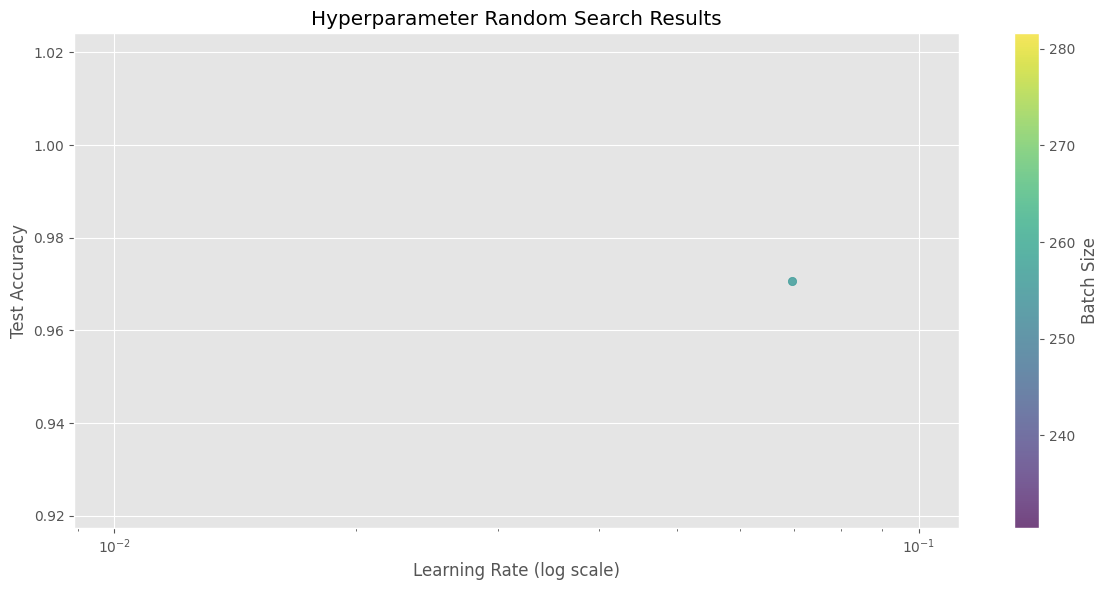


Top 5 Configurations:
   Learning Rate  Batch Size Optimizer  Test Accuracy  Test Loss  \
0       0.069519         256       sgd       0.970741   0.095555   

   Final Train Loss  Final Test Loss  Final Train Accuracy  \
0            0.0958         0.095555              0.970786   

   Final Test Accuracy  
0             0.970741  

Best Configuration:
Best Accuracy: 0.9707
Best Params: {'weight_decay': 0.00046415888336127773, 'scheduler_step_size': 5, 'scheduler_gamma': 0.9, 'patience': 5, 'optimizer': 'sgd', 'num_epochs': 30, 'learning_rate': 0.06951927961775606, 'batch_size': 256}
Best Hyperparameters:
{'model': LogisticRegression(
  (linear): Linear(in_features=135, out_features=1, bias=True)
), 'best_params': {'weight_decay': 0.00046415888336127773, 'scheduler_step_size': 5, 'scheduler_gamma': 0.9, 'patience': 5, 'optimizer': 'sgd', 'num_epochs': 30, 'learning_rate': 0.06951927961775606, 'batch_size': 256}, 'results': [{'model': LogisticRegression(
  (linear): Linear(in_features=

In [18]:
param_distributions = {
    'learning_rate': np.logspace(-4, -1, 20),
    'batch_size': [32, 64, 128, 256],
    'optimizer': ['sgd', 'adam', 'rmsprop'],
    'weight_decay': np.logspace(-5, -2, 10),
    'num_epochs': [30, 50, 75, 100],
    'scheduler_step_size': [5, 10, 15],
    'scheduler_gamma': [0.5, 0.7, 0.9],
    'patience': [3, 5, 7]
}

hyperparameter_results = hyperparameter_random_search(folds_data=folds_data, param_distributions=param_distributions, n_iter_search=1) 
lr_p_grid = hyperparameter_results
print("Best Hyperparameters:")
print(lr_p_grid)

In [19]:
hpt_model = hyperparameter_results['model']  # result_dict should include your trained model
raw_probs, binary_preds = predict(hpt_model, exam_X_encoded, all_columns)

print(binary_preds)

pd.DataFrame(binary_preds, columns=[target_col]).to_csv("src/data/y_pred_hpt.csv", index=False)

[2 1 1 ... 2 1 2]
